##Week 4: Testing Sobel-Based Vehicle Orientation Estimation
In Week 4, the Sobel-Based Vehicle Orientation Estimation created in Week 3 will be appied to 20 cropped images.

The output will be compared with the ground-truth orientation from the DRASHTI-HaOBB annotations.


The results will be used to calculate orientation error, mean absolute error, and analyse the performance of the sobel method.


## 1. Importing Libraries

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Reading the Ground-Truth Annotations

In [4]:
with open("0bGO_UHlP_zpWU.txt", "r") as f:
    lines = f.readlines()

lines = lines[1:]
vehicle_types = []
ground_truth = []

for line in lines:
    parts = line.split()
    vehicle_types.append(parts[8])
    ground_truth.append(float(parts[10]))

## 3. Defining the 20 Vehicle Images

In [5]:
image_files = [
    "v1_Sedan_17.1deg.jpg",
    "v2_SUV_181.38deg.jpg",
    "v3_MotorCycle_1.68deg.jpg",
    "v4_MotorCycle_36.32deg.jpg",
    "v5_MotorCycle_183.62deg.jpg",
    "v6_Sedan_270.0deg.jpg",
    "v7_SUV_181.88deg.jpg",
    "v8_MotorCycle_43.68deg.jpg",
    "v9_PickUp_178.04deg.jpg",
    "v10_MotorCycle_270.0deg.jpg",
    "v11_MotorCycle_270.0deg.jpg",
    "v12_MotorCycle_270.0deg.jpg",
    "v13_SUV_250.0deg.jpg",
    "v14_Van_0.0deg.jpg",
    "v15_AutoRicksaw_79.9deg.jpg",
    "v16_Van_101.4deg.jpg",
    "v17_MotorCycle_77.9deg.jpg",
    "v18_AutoRicksaw_294.3deg.jpg",
    "v19_AutoRicksaw_0.0deg.jpg",
    "v20_Tanker_177.4deg.jpg"
]

print("Number of images:", len(image_files))

Number of images: 20


## 4. Converting Ground-Truth Angles to a 0°–90° Scale

In [6]:
ground_truth_converted = []

for angle in ground_truth:
    angle = angle % 180
    if angle > 90:
        angle = 180 - angle
    ground_truth_converted.append(angle)

print(ground_truth_converted)

[17.1, 1.3799999999999955, 1.68, 36.32, 3.6200000000000045, 90.0, 1.8799999999999955, 43.68, 1.960000000000008, 90.0, 90.0, 90.0, 70.0, 0.0, 79.9, 78.6, 77.9, 65.69999999999999, 0.0, 2.5999999999999943]


## 5. Applying the Sobel Method to the 20 Vehicle Crops

In [7]:
estimated_angles = []

for image_file in image_files:
    img = cv2.imread(image_file)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    gradient_magnitude = np.uint8(
        255 * gradient_magnitude / gradient_magnitude.max()
    )

    gradient_direction = np.degrees(
        np.arctan2(sobel_y, sobel_x)
    )

    angles = gradient_direction.flatten()
    magnitudes = gradient_magnitude.flatten()

    hist, bins = np.histogram(
        angles,
        bins=180,
        range=(-90, 90),
        weights=magnitudes
    )

    dominant_angle = bins[np.argmax(hist)]

    orientation = abs(dominant_angle)

    estimated_angles.append(orientation)

## 6. Creating the Results Table

In [8]:
results = pd.DataFrame({
    "Vehicle": image_files,
    "Type": vehicle_types,
    "Ground Truth": ground_truth,
    "Ground Truth (0-90)": ground_truth_converted,
    "Sobel Estimated (0-90)": estimated_angles
})

results

,Vehicle,Type,Ground Truth,Ground Truth (0-90),Sobel Estimated (0-90)
0,v1_Sedan_17.1deg.jpg,Sedan,17.10,17.10,11.0
1,v2_SUV_181.38deg.jpg,SUV,181.38,1.38,63.0
2,v3_MotorCycle_1.68deg.jpg,MotorCycle,1.68,1.68,3.0
3,v4_MotorCycle_36.32deg.jpg,MotorCycle,36.32,36.32,5.0
4,v5_MotorCycle_183.62deg.jpg,MotorCycle,183.62,3.62,71.0
5,v6_Sedan_270.0deg.jpg,Sedan,270.00,90.00,23.0
6,v7_SUV_181.88deg.jpg,SUV,181.88,1.88,51.0
7,v8_MotorCycle_43.68deg.jpg,MotorCycle,43.68,43.68,21.0
8,v9_PickUp_178.04deg.jpg,PickUp,178.04,1.96,48.0
9,v10_MotorCycle_270.0deg.jpg,MotorCycle,270.00,90.00,79.0


## 7. Calculating Orientation Error

In [9]:
results["Error"] = abs(
    results["Sobel Estimated (0-90)"] -
    results["Ground Truth (0-90)"]
)

results

,Vehicle,Type,Ground Truth,Ground Truth (0-90),Sobel Estimated (0-90),Error
0,v1_Sedan_17.1deg.jpg,Sedan,17.10,17.10,11.0,6.10
1,v2_SUV_181.38deg.jpg,SUV,181.38,1.38,63.0,61.62
2,v3_MotorCycle_1.68deg.jpg,MotorCycle,1.68,1.68,3.0,1.32
3,v4_MotorCycle_36.32deg.jpg,MotorCycle,36.32,36.32,5.0,31.32
4,v5_MotorCycle_183.62deg.jpg,MotorCycle,183.62,3.62,71.0,67.38
5,v6_Sedan_270.0deg.jpg,Sedan,270.00,90.00,23.0,67.00
6,v7_SUV_181.88deg.jpg,SUV,181.88,1.88,51.0,49.12
7,v8_MotorCycle_43.68deg.jpg,MotorCycle,43.68,43.68,21.0,22.68
8,v9_PickUp_178.04deg.jpg,PickUp,178.04,1.96,48.0,46.04
9,v10_MotorCycle_270.0deg.jpg,MotorCycle,270.00,90.00,79.0,11.00


## 8. Calculating Error Statistics

In [10]:
mae = results["Error"].mean()
minimum_error = results["Error"].min()
maximum_error = results["Error"].max()

print("Mean Absolute Error:", round(mae, 2), "degrees")
print("Minimum Error:", round(minimum_error, 2), "degrees")
print("Maximum Error:", round(maximum_error, 2), "degrees")

Mean Absolute Error: 33.9 degrees
Minimum Error: 1.32 degrees
Maximum Error: 67.38 degrees


## 9. Plotting Orientation Error for Each Vehicle

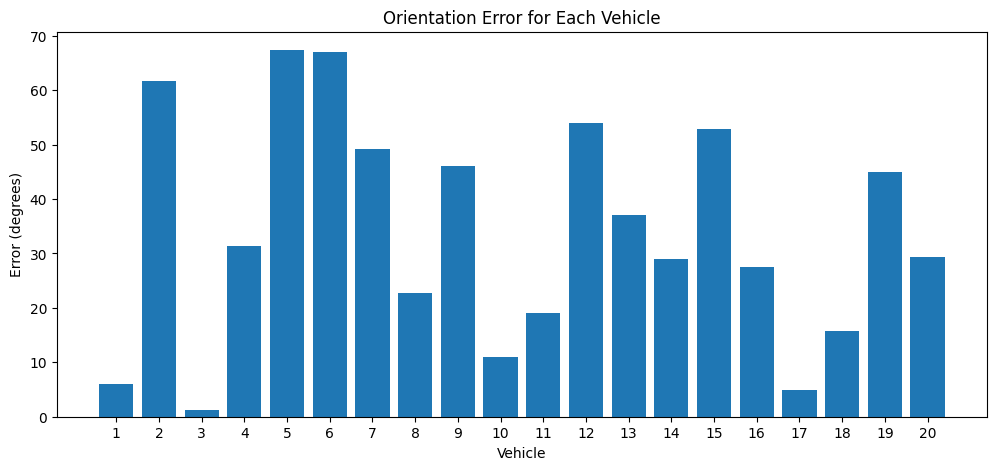

In [11]:
plt.figure(figsize=(12, 5))

plt.bar(
    range(1, 21),
    results["Error"]
)

plt.xlabel("Vehicle")
plt.ylabel("Error (degrees)")
plt.title("Orientation Error for Each Vehicle")
plt.xticks(range(1, 21))
plt.show()